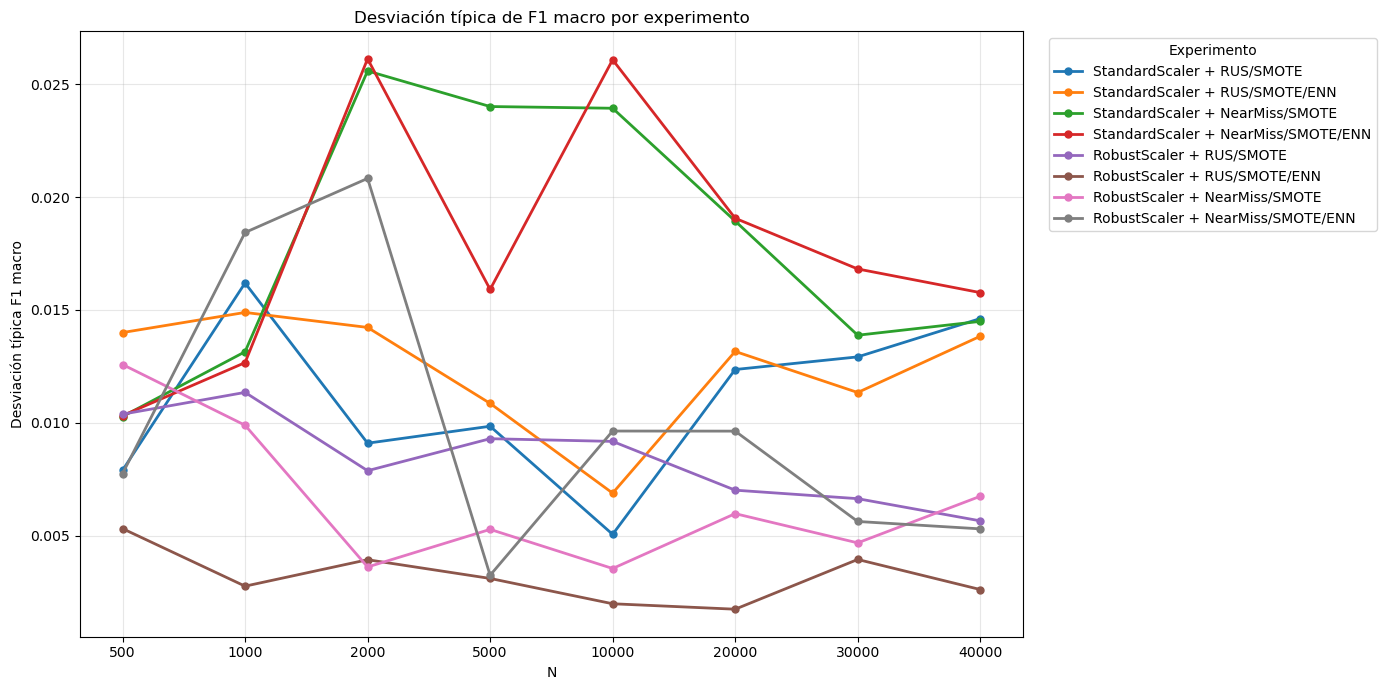

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC17/03_analisis/graficas/std_f1_macro_por_experimento.pdf



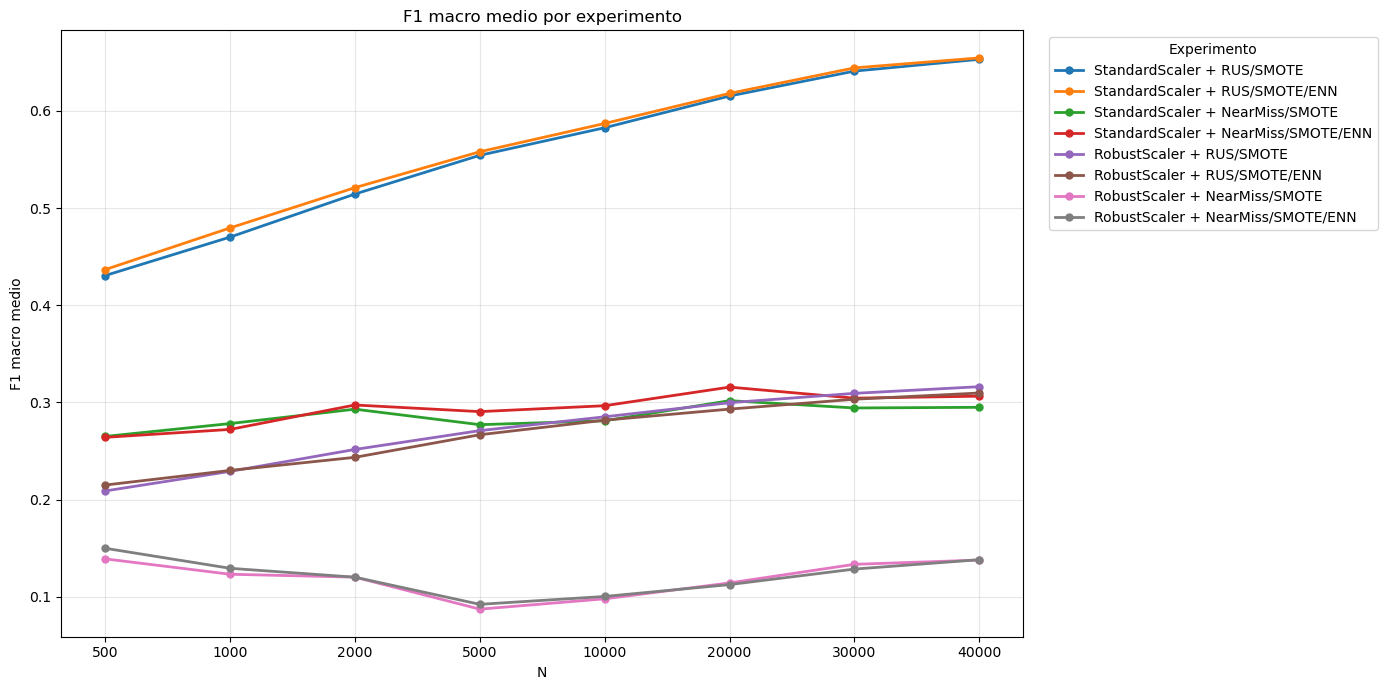

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC17/03_analisis/graficas/media_f1_macro_por_experimento.pdf



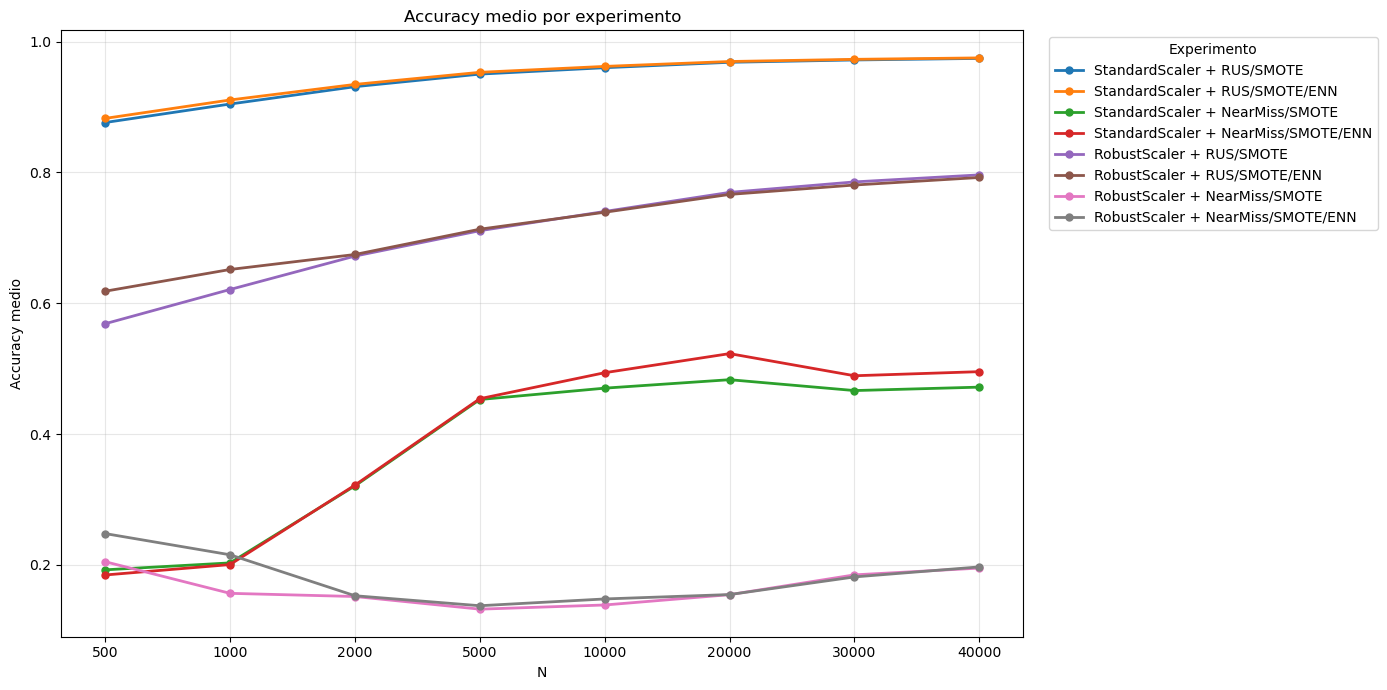

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC17/03_analisis/graficas/media_accuracy_por_experimento.pdf



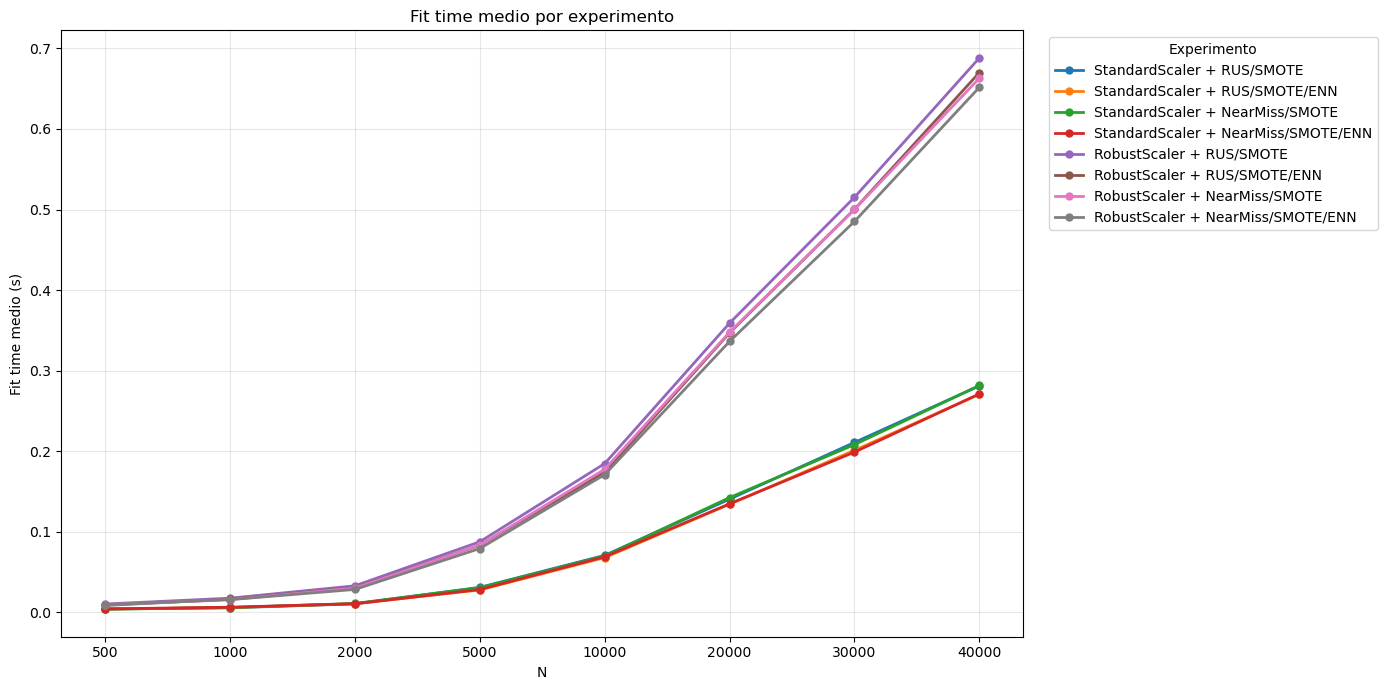

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC17/03_analisis/graficas/media_fit_time_por_experimento.pdf



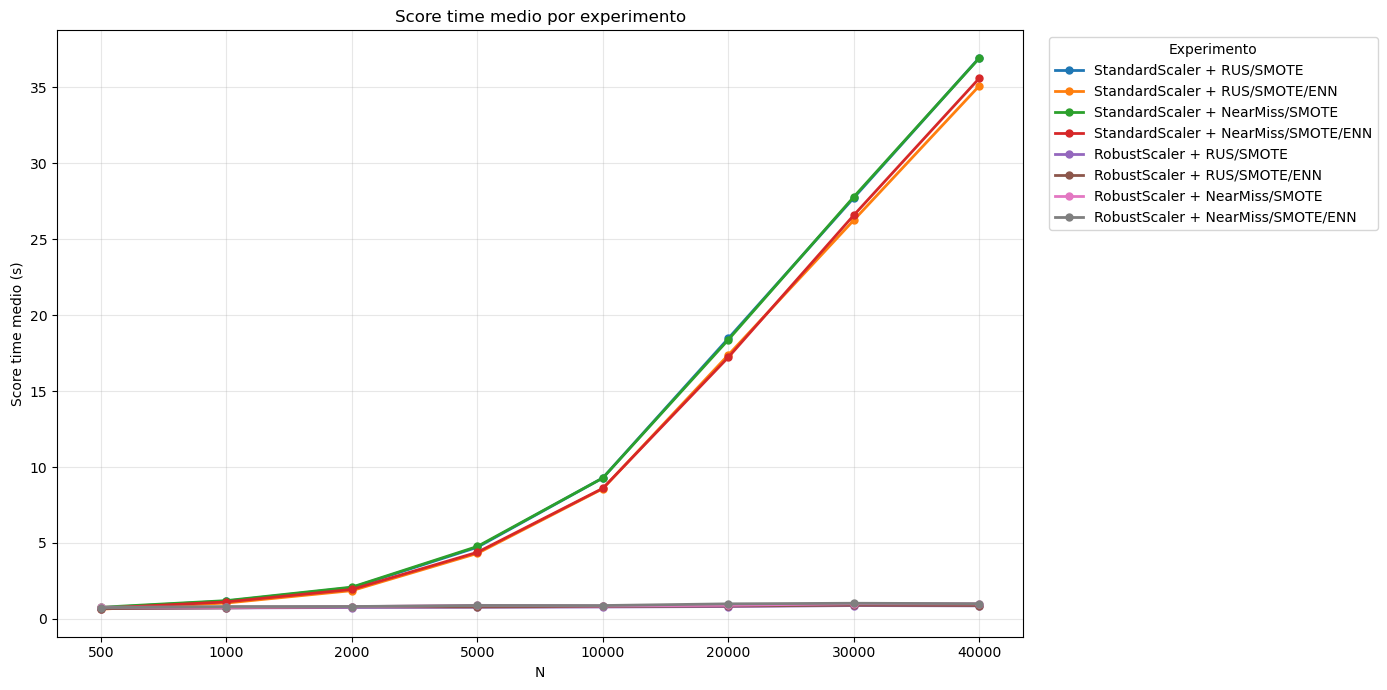

Gráfica guardada en:
/home/ana/Documentos/TFG/TFG_FASE_0/03_codigo/CIC17/03_analisis/graficas/media_score_time_por_experimento.pdf



In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


RUTA_RESULTADOS = Path("resultados.csv")
RUTA_GRAFICAS = Path("graficas")
RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)

# El CSV tiene una primera fila de grupos y la cabecera real en la segunda fila.
df = pd.read_csv(RUTA_RESULTADOS, header=1)

# En el CSV el nombre del experimento solo aparece en la primera fila de cada bloque.
df["DESCRIPCIÓN EXPERIMENTO"] = df["DESCRIPCIÓN EXPERIMENTO"].ffill()

columnas_metricas = [
    "N",
    "σ F1 MACRO",
    "μ F1 MACRO",
    "μ ACCURACY",
    "μ FIT TIME",
    "μ SCORE TIME",
]

for columna in columnas_metricas:
    df[columna] = pd.to_numeric(df[columna])

n_values = sorted(df["N"].unique())
x_pos = np.arange(len(n_values))
mapa_x = dict(zip(n_values, x_pos))


def graficar_metrica_por_experimento(columna, ylabel, titulo, nombre_pdf):
    plt.figure(figsize=(14, 7))

    for experimento, df_exp in df.groupby("DESCRIPCIÓN EXPERIMENTO", sort=False):
        df_exp = df_exp.sort_values("N")
        plt.plot(
            df_exp["N"].map(mapa_x),
            df_exp[columna],
            marker="o",
            linewidth=2,
            markersize=5,
            label=experimento,
        )

    plt.xticks(x_pos, [str(int(n)) for n in n_values])
    plt.xlabel("N")
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Experimento", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    ruta_salida = RUTA_GRAFICAS / nombre_pdf
    plt.savefig(ruta_salida, bbox_inches="tight")
    plt.show()

    print("Gráfica guardada en:")
    print(ruta_salida.resolve())
    print()


graficar_metrica_por_experimento(
    "σ F1 MACRO",
    "Desviación típica F1 macro",
    "Desviación típica de F1 macro por experimento",
    "std_f1_macro_por_experimento.pdf",
)

graficar_metrica_por_experimento(
    "μ F1 MACRO",
    "F1 macro medio",
    "F1 macro medio por experimento",
    "media_f1_macro_por_experimento.pdf",
)

graficar_metrica_por_experimento(
    "μ ACCURACY",
    "Accuracy medio",
    "Accuracy medio por experimento",
    "media_accuracy_por_experimento.pdf",
)

graficar_metrica_por_experimento(
    "μ FIT TIME",
    "Fit time medio (s)",
    "Fit time medio por experimento",
    "media_fit_time_por_experimento.pdf",
)

graficar_metrica_por_experimento(
    "μ SCORE TIME",
    "Score time medio (s)",
    "Score time medio por experimento",
    "media_score_time_por_experimento.pdf",
)
